# "Machine Learning \& Deep Learning Applications in Modern Power Systems"
## Department of Electrical Engineering - PMEC, Berhampur
### Instructor: Dr. Suryalok Dash 

# Day 4: Exercise Notebook
**Task:** Complete the missing code sections marked with `### YOUR CODE HERE ###`.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# We provide a synthetic dataset for predicting hourly power consumption (kWh) based on temperature and factory activity.
data = {
    'Temperature_C': np.random.uniform(15, 40, 200),
    'Machines_Running': np.random.randint(1, 50, 200),
}
df = pd.DataFrame(data)
# Synthetic target generation
df['Power_Consumption_kWh'] = (df['Temperature_C'] * 2.5) + (df['Machines_Running'] * 15.0) + np.random.normal(0, 10, 200)

# Task 1: Extract features ('Temperature_C', 'Machines_Running') into variable X
X = df[['Temperature_C', 'Machines_Running']]

# Task 2: Extract the target ('Power_Consumption_kWh') into variable y
y = df['Power_Consumption_kWh']

# Task 3: Perform a train-test split using test_size=0.25 and random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Task 4: Initialize the StandardScaler
scaler = StandardScaler()

# Task 5: Fit and transform the X_train data. Also transform the X_test data.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Task 6: Initialize the LinearRegression model as 'lr_model'
lr_model = LinearRegression()

In [10]:
# Task 7: Train the linear regression model using the scaled training data and training labels
lr_model.fit(X_train_scaled, y_train)

# Task 8: Generate predictions using the scaled test data. Store them in a variable called 'y_pred'
y_pred = lr_model.predict(X_test_scaled)

# Task 9: Print the learned coefficients (weights) of the model using the .coef_ attribute
print("Model Coefficients:", lr_model.coef_)

Model Coefficients: [ 14.7494434  217.12789509]


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Task 10: Calculate and print the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

# Task 11: Calculate and print the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse}")

# Task 12: Calculate and print the R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

MAE: 7.656227294680186
MSE: 104.68669433247167
R2 Score: 0.9971631097179959


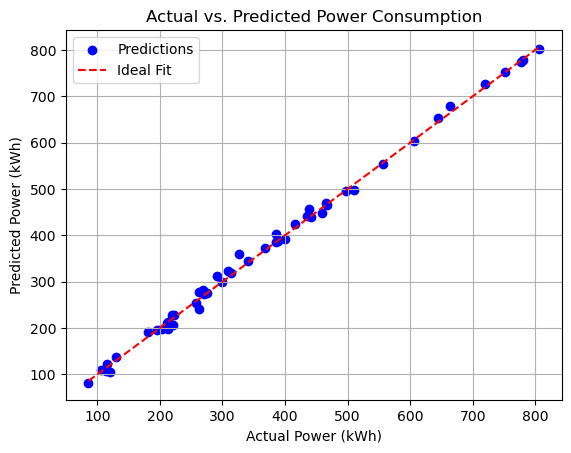

In [14]:
import matplotlib.pyplot as plt

# Task 13: Create a scatter plot of Actual values (y_test) vs Predicted values (y_pred)
# Hint: plt.scatter(x_values, y_values)
plt.scatter(y_test, y_pred, color = 'blue', label = 'Predictions')

# Task 14: Add an ideal prediction line. Plot a line from (min(y_test), min(y_test)) to (max(y_test), max(y_test))
# Use color='red' and linestyle='--'
mn, mx = float(y_test.min()), float(y_test.max())
plt.plot([mn, mx], [mn, mx], color='red', linestyle='--', label='Ideal Fit')

# Task 15: Add axis labels ("Actual Power (kWh)" and "Predicted Power (kWh)") and a title, then show the plot
plt.xlabel("Actual Power (kWh)")
plt.ylabel("Predicted Power (kWh)")
plt.title("Actual vs. Predicted Power Consumption")
plt.legend()
plt.grid(True)
plt.show()